# dLuxShera ML Campaign Tracker

This notebook is a persistent local tracker for ML inverse-model campaigns. It analyzes compact artifacts already synchronized under `Results/hpc_imports/ml`; it does not run SSH, submit jobs, train models, or evaluate the frozen test set.

Refresh workflow: run `work/experiments/ml/analysis/sync_results.py` outside the notebook, then rerun this notebook. Runs are discovered recursively from `run_manifest.json` artifacts, so newly synchronized studies should appear without editing notebook source.

## 1. Setup and Local Result Mirror

The loader treats run artifacts as authoritative. The headline metrics below are Fisher-scaled initializer metrics, comparing the learned correction against the zero-correction baseline.

In [1]:
from pathlib import Path
import sys

def find_repo_root(start: Path | None = None) -> Path:
    path = (start or Path.cwd()).resolve()
    for candidate in (path, *path.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "work" / "experiments" / "ml").exists():
            return candidate
    raise RuntimeError("Could not find the dLuxShera repository root.")

REPO_ROOT = find_repo_root()
ANALYSIS_DIR = REPO_ROOT / "work" / "experiments" / "ml" / "analysis"
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

RESULTS_ROOT = REPO_ROOT / "Results" / "hpc_imports" / "ml"

# Campaign filters
STUDIES = None #["S05"]          # e.g. ["S05"] or ["S01", "S05"]
EXPERIMENTS = None #["S05-E01", "S05-E02", "S05-E03", "S05-E04"]      # e.g. ["S05-E01", "S05-E04"]
INCLUDE_RUNS = None     # e.g. ["S05-E01-R001", "S05-E04-R001"]
EXCLUDE_RUN_PATTERNS = ["SMOKE"]  # substring matches against run_id

RMSE_THRESHOLDS = [100, 90, 80, 75]
SELECTED_RUN = None

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from campaign_analysis import evaluation_contract_summary, load_campaign, time_to_thresholds
import campaign_plots as cplots

campaign = load_campaign([RESULTS_ROOT])
runs = campaign.runs.copy()

# Apply campaign/run filters.
if not runs.empty:
    mask = pd.Series(True, index=runs.index)

    if STUDIES is not None:
        mask &= runs["study_id"].isin(STUDIES)

    if EXPERIMENTS is not None:
        mask &= runs["experiment_id"].isin(EXPERIMENTS)

    if INCLUDE_RUNS is not None:
        mask &= runs["run_id"].isin(INCLUDE_RUNS)

    for pattern in EXCLUDE_RUN_PATTERNS:
        mask &= ~runs["run_id"].str.contains(pattern, case=False, na=False)

    runs = runs.loc[mask].copy()

selected_run_ids = set(runs["run_id"]) if not runs.empty else set()

history = campaign.history[
    campaign.history["run_id"].isin(selected_run_ids)
].copy()

parameters = campaign.parameters[
    campaign.parameters["run_id"].isin(selected_run_ids)
].copy()

slices = campaign.slices[
    campaign.slices["run_id"].isin(selected_run_ids)
].copy()

distance_bins = campaign.distance_bins[
    campaign.distance_bins["run_id"].isin(selected_run_ids)
].copy()

display(Markdown(f"**Local results root:** `{RESULTS_ROOT}`"))
if campaign.sync_manifests.empty:
    display(Markdown("**Last sync:** no `sync_manifest.json` found."))
else:
    display(campaign.sync_manifests[[c for c in ["site", "synced_at_utc", "remote_root", "local_root"] if c in campaign.sync_manifests]].sort_values("synced_at_utc", ascending=False))

if runs.empty:
    display(Markdown("No ML campaign runs were discovered. Synchronize compact results, then rerun the notebook."))
else:
    sites = sorted(str(v) for v in runs["site"].dropna().unique()) if "site" in runs else []
    studies = sorted(str(v) for v in runs["study_id"].dropna().unique()) if "study_id" in runs else []
    status_counts = runs["status"].value_counts().to_dict() if "status" in runs else {}
    display(Markdown(f"**Discovered:** {len(runs)} runs across sites {sites} and studies {studies}. Status counts: `{status_counts}`."))

for message in campaign.warnings:
    display(Markdown(f"**Loader warning:** {message}"))

**Local results root:** `/Users/dmckeith/Documents/GitHub/dluxshera-sandbox/Results/hpc_imports/ml`

,site,synced_at_utc,remote_root,local_root
0,tacc_ls6,2026-09-07T22:17:56.922455+00:00,/work/11689/dmckeith/ls6/dLuxShera-Results/ml/,Results/hpc_imports/ml/ls6


**Discovered:** 13 runs across sites ['ls6'] and studies ['S01', 'S05']. Status counts: `{'complete': 13}`.

## 2. Campaign Overview

The leaderboard keeps provenance visible because source commits and validation artifact identities define which comparisons are scientifically clean.

In [2]:
overview_cols = [
    "study_id", "experiment_id", "run_id", "seed", "status", "model_comparator",
    "initial_learning_rate", "lr_scheduler_name", "epochs_completed", "best_epoch",
    "best_fisher_rmse", "zero_baseline_fisher_rmse", "mse_skill", "rmse_reduction",
    "total_training_seconds", "source_commit", "validation_manifest_sha256", "test_evaluated",
]
if runs.empty:
    display(Markdown("No run table available."))
else:
    table = runs[[c for c in overview_cols if c in runs.columns]].sort_values("best_fisher_rmse", na_position="last").copy()
    for col in ["best_fisher_rmse", "zero_baseline_fisher_rmse"]:
        if col in table:
            table[col] = table[col].map(lambda v: np.nan if pd.isna(v) else round(float(v), 3))
    for col in ["mse_skill", "rmse_reduction"]:
        if col in table:
            table[col] = table[col].map(lambda v: np.nan if pd.isna(v) else round(float(v), 4))
    if "total_training_seconds" in table:
        table["runtime_min"] = (table["total_training_seconds"] / 60.0).round(2)
        table = table.drop(columns=["total_training_seconds"])
    display(table)

contract = evaluation_contract_summary(runs)
if not contract.empty:
    display(Markdown("### Evaluation Contract / Provenance"))
    display(contract)
    if contract.get("validation_manifest_sha256", pd.Series(dtype=object)).dropna().nunique() > 1:
        display(Markdown("**Warning:** selected runs use differing validation manifest identities."))
    if "test_evaluated" in contract and contract["test_evaluated"].fillna(False).any():
        display(Markdown("**Warning:** at least one selected run has `test_evaluated == True`."))

,study_id,experiment_id,run_id,seed,status,model_comparator,initial_learning_rate,lr_scheduler_name,epochs_completed,best_epoch,best_fisher_rmse,zero_baseline_fisher_rmse,mse_skill,rmse_reduction,source_commit,validation_manifest_sha256,test_evaluated,runtime_min
4,S01,S01-E03,S01-E03-R001,11,complete,concat_diff,0.0010,none,300,273,57.868,250.84,0.9468,0.7693,5687100cb148590980dfa343bd24ee9aff635ddc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,77.32
3,S01,S01-E02,S01-E02-R001,11,complete,concat_diff,0.0005,none,300,278,59.505,250.84,0.9437,0.7628,5687100cb148590980dfa343bd24ee9aff635ddc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,91.06
8,S01,S01-E06,S01-E06-R001,11,complete,concat_diff,0.0005,cosine_annealing,300,278,60.325,250.84,0.9422,0.7595,5687100cb148590980dfa343bd24ee9aff635ddc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,76.55
9,S01,S01-E07,S01-E07-R001,11,complete,concat_diff,0.0010,cosine_annealing,300,275,60.328,250.84,0.9422,0.7595,5687100cb148590980dfa343bd24ee9aff635ddc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,80.14
5,S01,S01-E04,S01-E04-R001,11,complete,concat_diff,0.0005,reduce_on_plateau,242,219,64.982,250.84,0.9329,0.7409,5687100cb148590980dfa343bd24ee9aff635ddc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,65.40
6,S01,S01-E05,S01-E05-R001,11,complete,concat_diff,0.0010,reduce_on_plateau,229,222,67.094,250.84,0.9285,0.7325,5687100cb148590980dfa343bd24ee9aff635ddc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,64.93
14,S05,S05-E04,S05-E04-R001,11,complete,concat_diff,0.0005,none,100,93,68.455,250.84,0.9255,0.7271,31b2516737f4aa6594da0f2b009768f981d75cfc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,27.48
11,S05,S05-E01,S05-E01-R001,11,complete,concat_diff,0.0005,none,100,99,72.326,250.84,0.9169,0.7117,31b2516737f4aa6594da0f2b009768f981d75cfc,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,35.82
0,S01,S01-E01,S01-E01-R001,11,complete,concat_diff,0.0005,none,100,99,72.468,250.84,0.9165,0.7111,NaN,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,28.88
2,S01,S01-E01,S01-E01-R003,47,complete,concat_diff,0.0005,none,100,93,74.328,250.84,0.9122,0.7037,NaN,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,False,23.97


### Evaluation Contract / Provenance

,run_id,study_id,experiment_id,source_commit,source_archive_id,prepared_dataset_hash,split_registry_content_sha256,validation_manifest_sha256,test_manifest_sha256,test_evaluated
0,S01-E01-R001,S01,S01-E01,NaN,NaN,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
1,S01-E01-R002,S01,S01-E01,NaN,NaN,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
2,S01-E01-R003,S01,S01-E01,NaN,NaN,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
3,S01-E02-R001,S01,S01-E02,5687100cb148590980dfa343bd24ee9aff635ddc,4546f4caccd653220708a56612869d22b02c9a24f4f42d...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
4,S01-E03-R001,S01,S01-E03,5687100cb148590980dfa343bd24ee9aff635ddc,4546f4caccd653220708a56612869d22b02c9a24f4f42d...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
5,S01-E04-R001,S01,S01-E04,5687100cb148590980dfa343bd24ee9aff635ddc,4546f4caccd653220708a56612869d22b02c9a24f4f42d...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
6,S01-E05-R001,S01,S01-E05,5687100cb148590980dfa343bd24ee9aff635ddc,4546f4caccd653220708a56612869d22b02c9a24f4f42d...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
8,S01-E06-R001,S01,S01-E06,5687100cb148590980dfa343bd24ee9aff635ddc,4546f4caccd653220708a56612869d22b02c9a24f4f42d...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
9,S01-E07-R001,S01,S01-E07,5687100cb148590980dfa343bd24ee9aff635ddc,4546f4caccd653220708a56612869d22b02c9a24f4f42d...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False
11,S05-E01-R001,S05,S05-E01,31b2516737f4aa6594da0f2b009768f981d75cfc,b0aea608397a670be4decfc7f8141df93cf41df73ad5ee...,4cdc325fbf8d4a0e07195ab075bea6f5035dfc01c9990c...,29f0e95c3819cbeb5ce00aafb593445510723ea5fc20e2...,68ccd41a35d286c8b060f291eef6c788a6b0d97c966086...,None,False


## 3. Training / Optimization Behavior

These plots compare frozen validation behavior, not training loss. Fixed-LR historical runs are populated from resolved config only when the LR is unambiguous; scheduler-enabled histories use recorded per-epoch LR columns.

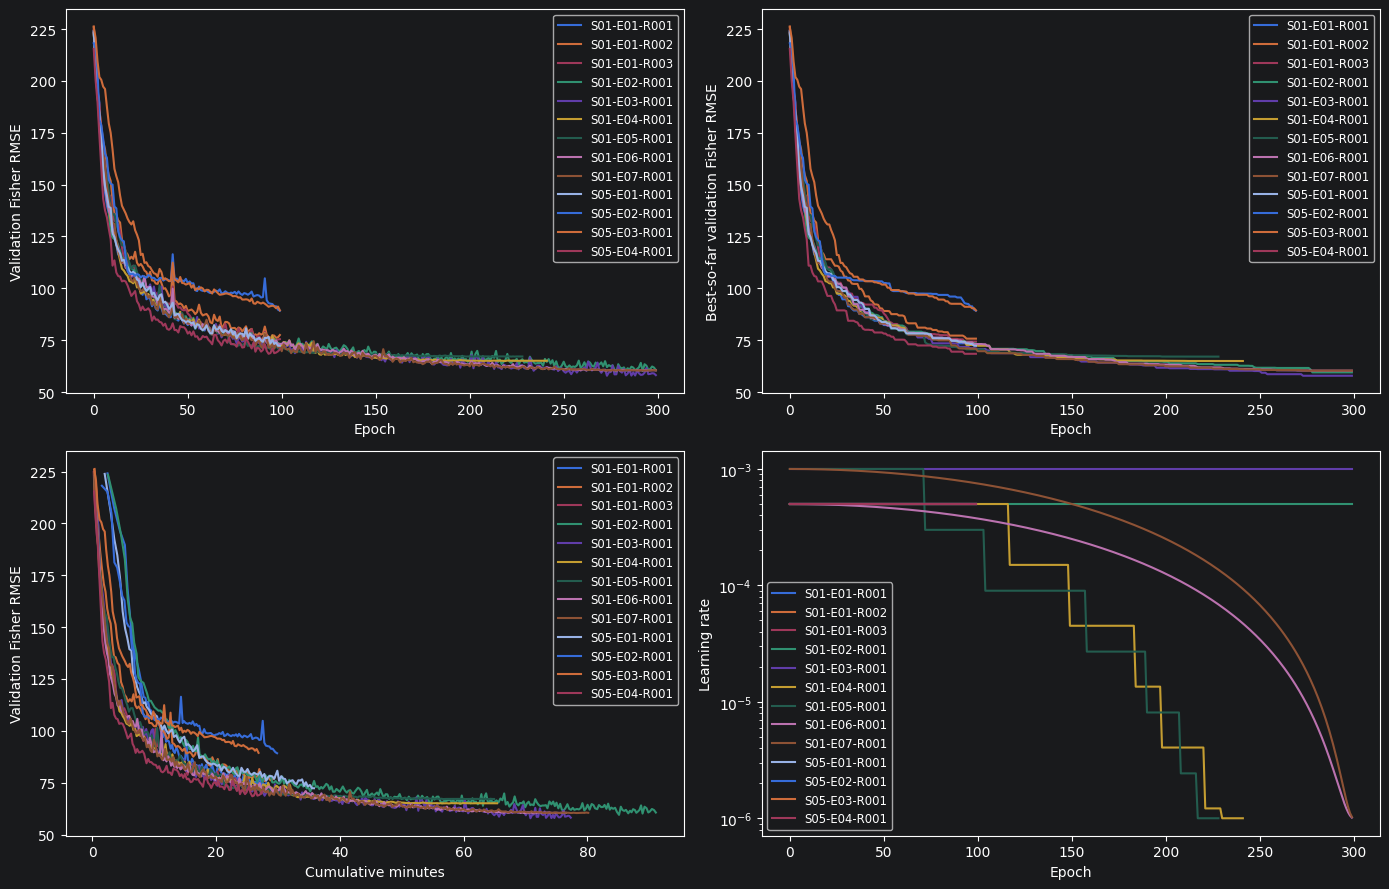

RMSE threshold,75.0,80.0,90.0,100.0
run_id,,,,
S01-E01-R001,87.0,60.0,35.0,26.0
S01-E01-R002,NaN,77.0,51.0,38.0
S01-E01-R003,94.0,64.0,48.0,32.0
S01-E02-R001,89.0,63.0,44.0,29.0
S01-E03-R001,77.0,63.0,41.0,32.0
S01-E04-R001,87.0,63.0,38.0,26.0
S01-E05-R001,73.0,59.0,38.0,29.0
S01-E06-R001,90.0,63.0,38.0,32.0
S01-E07-R001,80.0,59.0,35.0,26.0


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
cplots.plot_validation_rmse_vs_epoch(history, ax=axes[0, 0])
cplots.plot_best_so_far_rmse_vs_epoch(history, ax=axes[0, 1])
cplots.plot_validation_rmse_vs_wall_minutes(history, ax=axes[1, 0])
cplots.plot_learning_rate_vs_epoch(history, ax=axes[1, 1])
fig.tight_layout()
plt.show()

thresholds = time_to_thresholds(history, RMSE_THRESHOLDS)
if thresholds.empty:
    display(Markdown("No time-to-threshold data available."))
else:
    display(thresholds.pivot(index="run_id", columns="threshold", values="epoch_number").rename_axis(columns="RMSE threshold"))

## 4. Headline Initializer Performance

`mse_skill = 0` means zero correction and the network are equivalent. Positive skill improves upon doing nothing, `1` is perfect correction, and negative skill worsens the Fisher-scaled starting error. These are initializer-quality metrics, not final ADORA astrometric precision.

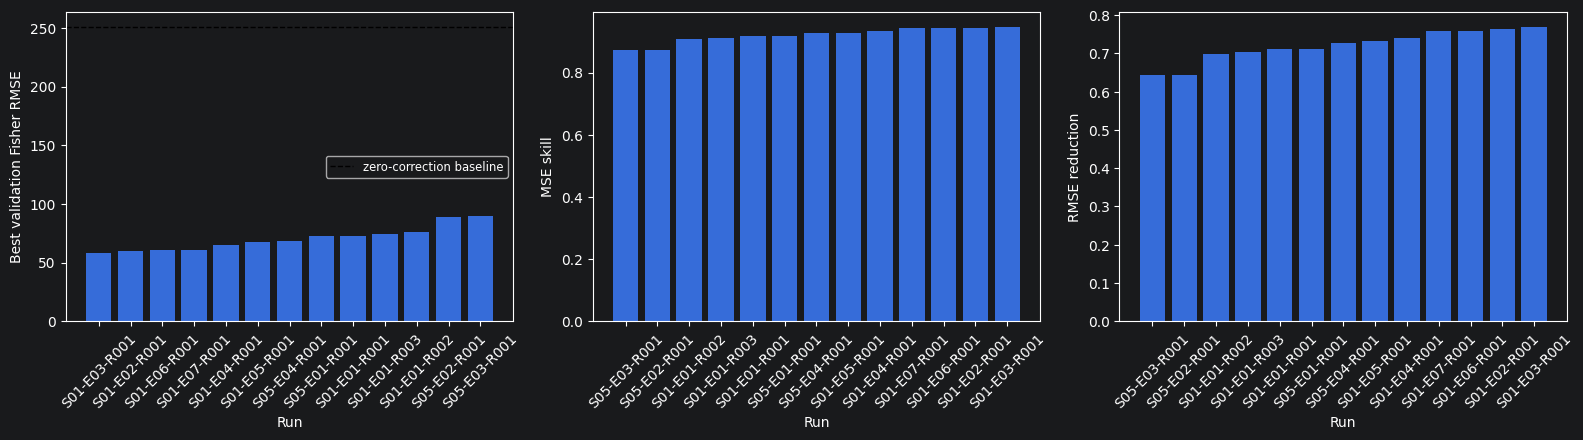

,run_id,zero_baseline_fisher_rmse,learned_fisher_rmse,mse_skill,rmse_reduction
4,S01-E03-R001,250.839606,57.867599,0.946780,0.769304
3,S01-E02-R001,250.839606,59.504592,0.943726,0.762778
8,S01-E06-R001,250.839606,60.324977,0.942163,0.759508
9,S01-E07-R001,250.839606,60.328201,0.942157,0.759495
5,S01-E04-R001,250.839606,64.982355,0.932888,0.740941
6,S01-E05-R001,250.839606,67.094150,0.928455,0.732522
14,S05-E04-R001,250.839606,68.454776,0.925524,0.727097
11,S05-E01-R001,250.839606,72.326249,0.916862,0.711663
0,S01-E01-R001,250.839606,72.468136,0.916535,0.711098
2,S01-E01-R003,250.839606,74.327806,0.912197,0.703684


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
cplots.plot_best_fisher_rmse_by_run(runs, ax=axes[0])
baseline_line_added = cplots.add_common_zero_baseline(axes[0], runs)
if not baseline_line_added and not runs.empty:
    display(Markdown("Shared zero-correction baseline line omitted because selected runs do not share a compatible validation manifest or matching baseline RMSE."))
cplots.plot_mse_skill_by_run(runs, ax=axes[1])
cplots.plot_rmse_reduction_by_run(runs, ax=axes[2])
fig.tight_layout()
plt.show()

metric_cols = ["run_id", "zero_baseline_fisher_rmse", "learned_fisher_rmse", "mse_skill", "rmse_reduction"]
display(runs[[c for c in metric_cols if c in runs]].sort_values("mse_skill", ascending=False, na_position="last") if not runs.empty else pd.DataFrame())

## 5. S05 Architecture Study

Known Wave-1 labels are used only for display. Run discovery remains artifact-driven.

,architecture_label,run_id,model_comparator,embedding_dim,encoder_hidden_dim,head_hidden_dim,best_fisher_rmse,mse_skill,source_commit
11,S05-E01 - baseline concat-diff,S05-E01-R001,concat_diff,128,256,256,72.326249,0.916862,31b2516737f4aa6594da0f2b009768f981d75cfc
12,S05-E02 - difference-only,S05-E02-R001,difference,128,256,256,89.217078,0.873496,31b2516737f4aa6594da0f2b009768f981d75cfc
13,S05-E03 - small encoder,S05-E03-R001,concat_diff,64,128,128,89.395143,0.872991,31b2516737f4aa6594da0f2b009768f981d75cfc
14,S05-E04 - large encoder,S05-E04-R001,concat_diff,256,512,512,68.454776,0.925524,31b2516737f4aa6594da0f2b009768f981d75cfc


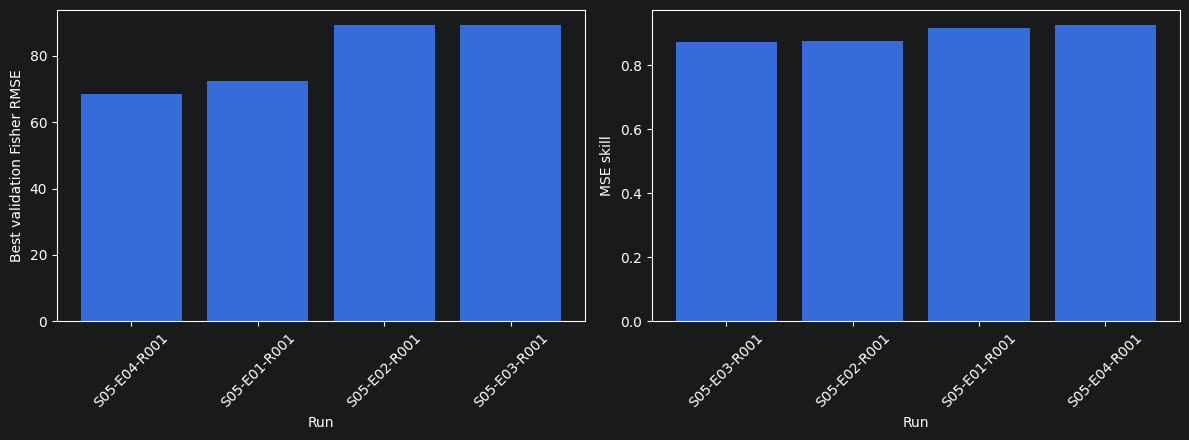

In [5]:
s05_labels = {
    "S05-E01": "S05-E01 - baseline concat-diff",
    "S05-E02": "S05-E02 - difference-only",
    "S05-E03": "S05-E03 - small encoder",
    "S05-E04": "S05-E04 - large encoder",
}
s05 = runs[runs.get("study_id", pd.Series(dtype=object)) == "S05"].copy() if not runs.empty else pd.DataFrame()
if s05.empty:
    display(Markdown("S05 results are not yet available in the local mirror."))
else:
    s05["architecture_label"] = s05["experiment_id"].map(s05_labels).fillna(s05["experiment_id"])
    display(s05.sort_values("experiment_id")[["architecture_label", "run_id", "model_comparator", "embedding_dim", "encoder_hidden_dim", "head_hidden_dim", "best_fisher_rmse", "mse_skill", "source_commit"]])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    cplots.plot_best_fisher_rmse_by_run(s05, ax=axes[0])
    cplots.plot_mse_skill_by_run(s05, ax=axes[1])
    fig.tight_layout()
    plt.show()

## 6. S01 Optimization Study

This section is ready for S01-E02 through S01-E07 scheduler/fixed-LR comparisons. It executes cleanly while only historical or smoke runs are present.

,experiment_id,run_id,initial_learning_rate,lr_scheduler_name,best_fisher_rmse,best_epoch,epochs_completed,total_training_seconds,early_stopped,reached_max_epochs
0,S01-E01,S01-E01-R001,0.0005,none,72.468136,99,100,1732.660328,False,True
1,S01-E01,S01-E01-R002,0.0005,none,75.755874,94,100,1766.558289,False,True
2,S01-E01,S01-E01-R003,0.0005,none,74.327806,93,100,1438.286397,False,True
3,S01-E02,S01-E02-R001,0.0005,none,59.504592,278,300,5463.785579,False,True
4,S01-E03,S01-E03-R001,0.0010,none,57.867599,273,300,4638.997351,False,True
5,S01-E04,S01-E04-R001,0.0005,reduce_on_plateau,64.982355,219,242,3923.963531,True,False
6,S01-E05,S01-E05-R001,0.0010,reduce_on_plateau,67.094150,222,229,3895.693318,True,False
8,S01-E06,S01-E06-R001,0.0005,cosine_annealing,60.324977,278,300,4592.789330,False,True
9,S01-E07,S01-E07-R001,0.0010,cosine_annealing,60.328201,275,300,4808.596142,False,True


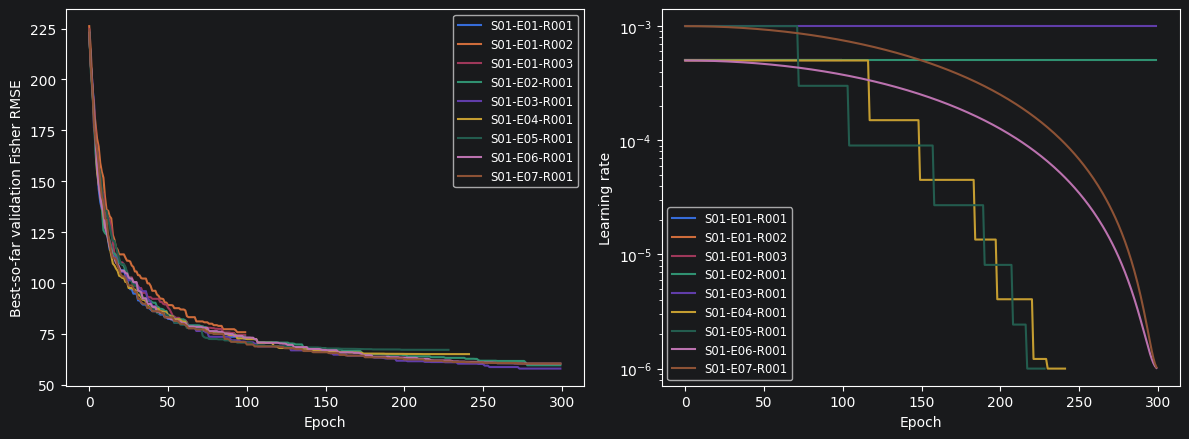

In [6]:
s01 = runs[runs.get("study_id", pd.Series(dtype=object)) == "S01"].copy() if not runs.empty else pd.DataFrame()
if s01.empty:
    display(Markdown("S01 optimization results are not yet available in the local mirror."))
else:
    display(s01[[c for c in ["experiment_id", "run_id", "initial_learning_rate", "lr_scheduler_name", "best_fisher_rmse", "best_epoch", "epochs_completed", "total_training_seconds", "early_stopped", "reached_max_epochs"] if c in s01]].sort_values(["experiment_id", "run_id"]))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    cplots.plot_best_so_far_rmse_vs_epoch(history[history.get("study_id", pd.Series(dtype=object)) == "S01"], ax=axes[0])
    cplots.plot_learning_rate_vs_epoch(history[history.get("study_id", pd.Series(dtype=object)) == "S01"], ax=axes[1])
    fig.tight_layout()
    plt.show()

## 7. Nuisance Generalization

Seen vs held-out nuisance slices show whether architecture or optimization changes introduce a nuisance-generalization gap.

,run_id,eval_slice,sample_count,model_fisher_rmse,baseline_fisher_rmse,mse_skill,rmse_reduction,median_relative_residual_norm
0,S01-E01-R001,heldout_science_heldout_nuisance,1024,71.310412,242.688715,0.913661,0.706165,0.268078
1,S01-E01-R001,heldout_science_seen_nuisance,1024,73.607654,258.733846,0.919064,0.715508,0.287763
2,S01-E01-R002,heldout_science_heldout_nuisance,1024,74.768806,242.688715,0.905083,0.691915,0.279463
3,S01-E01-R002,heldout_science_seen_nuisance,1024,76.730244,258.733846,0.912052,0.703439,0.318369
4,S01-E01-R003,heldout_science_heldout_nuisance,1024,73.404333,242.688715,0.908516,0.697537,0.265759
5,S01-E01-R003,heldout_science_seen_nuisance,1024,75.239945,258.733846,0.915435,0.709199,0.294573
6,S01-E02-R001,heldout_science_heldout_nuisance,1024,58.045153,242.688715,0.942795,0.760825,0.150504
7,S01-E02-R001,heldout_science_seen_nuisance,1024,60.929083,258.733846,0.944545,0.764511,0.159483
8,S01-E03-R001,heldout_science_heldout_nuisance,1024,55.997239,242.688715,0.946760,0.769263,0.143348
9,S01-E03-R001,heldout_science_seen_nuisance,1024,59.679370,258.733846,0.946796,0.769341,0.168639


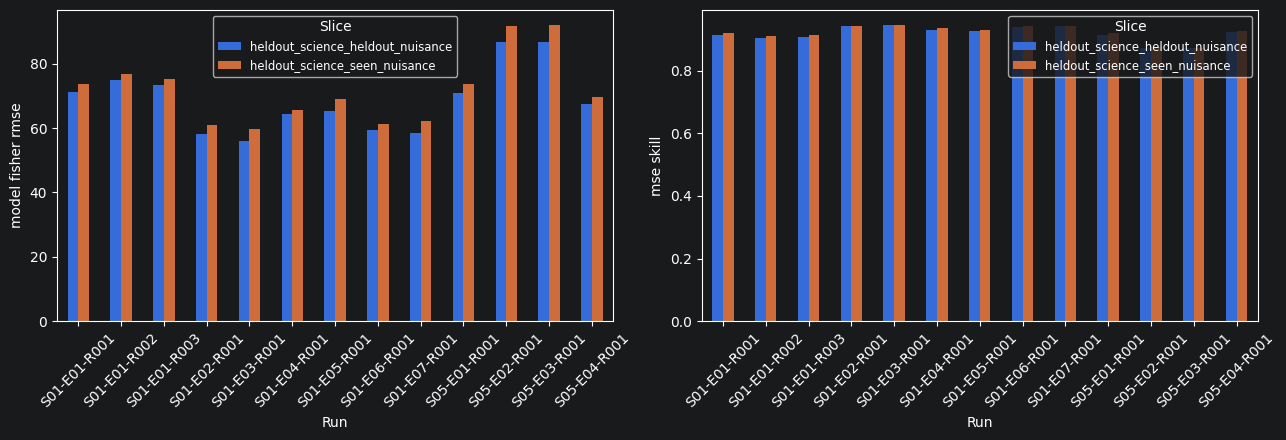

In [7]:
if slices.empty:
    display(Markdown("No evaluation-slice metrics are available."))
else:
    display(slices[["run_id", "eval_slice", "sample_count", "model_fisher_rmse", "baseline_fisher_rmse", "mse_skill", "rmse_reduction", "median_relative_residual_norm"]].sort_values(["run_id", "eval_slice"]))
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    cplots.plot_seen_vs_heldout_nuisance(slices, metric="model_fisher_rmse", ax=axes[0])
    cplots.plot_seen_vs_heldout_nuisance(slices, metric="mse_skill", ax=axes[1])
    fig.tight_layout()
    plt.show()

## 8. Per-Parameter Performance

Fisher skill is comparable across parameters. Physical RMSE is shown per parameter only, because physical units differ across the science vector.

,run_id,parameter_display,parameter_family,fisher_model_rmse,fisher_baseline_rmse,fisher_mse_skill,physical_rmse,physical_unit
0,S01-E01-R001,plate_scale_as_per_pix,source/global,29.547135,276.487455,0.988580,0.000071,arcsec/pix
1,S01-E01-R001,M1 Z4,M1,17.944719,302.979991,0.996492,3.046180,nm
2,S01-E01-R001,M1 Z5,M1,17.027748,53.691829,0.899423,3.004375,nm
3,S01-E01-R001,M1 Z6,M1,40.939351,484.122918,0.992849,3.501791,nm
4,S01-E01-R001,M1 Z7,M1,102.077459,278.808850,0.865956,0.648111,nm
...,...,...,...,...,...,...,...,...
295,S05-E04-R001,M2 Z10,M2,40.107461,145.505584,0.924021,6.058072,nm
296,S05-E04-R001,M2 Z11,M2,28.455391,146.808496,0.962431,1.617880,nm
297,S05-E04-R001,contrast,source/global,91.764686,142.590432,0.585838,0.047299,dimensionless
298,S05-E04-R001,log_flux_total,source/global,93.412578,146.542176,0.593664,0.002374,log flux


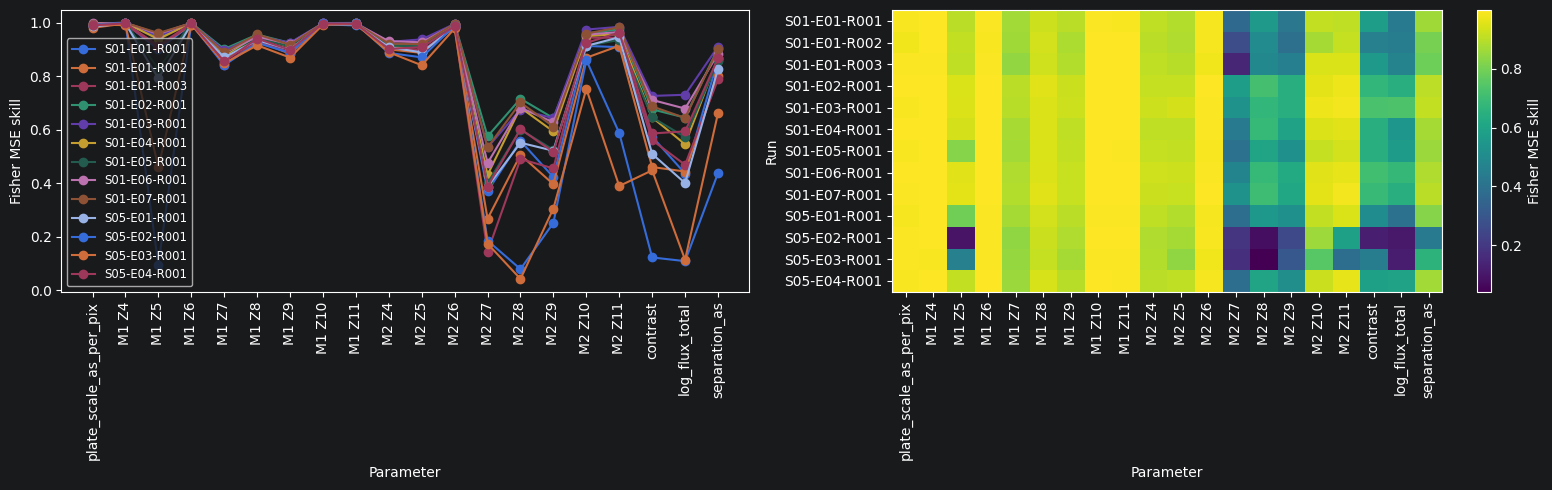

In [8]:
if parameters.empty:
    display(Markdown("No per-parameter metrics are available."))
else:
    display(parameters.sort_values(["run_id", "parameter_index"])[["run_id", "parameter_display", "parameter_family", "fisher_model_rmse", "fisher_baseline_rmse", "fisher_mse_skill", "physical_rmse", "physical_unit"]])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    cplots.plot_parameter_skill_by_run(parameters, ax=axes[0])
    cplots.plot_parameter_skill_heatmap(parameters, ax=axes[1])
    fig.tight_layout()
    plt.show()

## 9. Fisher-Distance / Capture Behavior

Absolute residual can increase with input distance even when fractional correction quality and direction improve. Preserve sample counts when interpreting bins.

,run_id,distance_bin,sample_count,mean_fisher_distance_l2,mse_skill,median_relative_residual_norm,mean_cosine_alignment,mean_correction_norm_ratio
0,S01-E01-R001,0-100,6,53.333333,0.889469,0.381558,0.945303,1.125620
1,S01-E01-R001,100-250,168,188.989149,0.604183,0.375312,0.842094,0.945755
2,S01-E01-R001,250-500,360,380.379466,0.706946,0.355626,0.856396,0.912537
3,S01-E01-R001,500-1000,702,719.826645,0.780546,0.348897,0.880778,0.888814
4,S01-E01-R001,1000-2000,716,1351.657251,0.927504,0.179935,0.954917,0.948639
...,...,...,...,...,...,...,...,...
85,S05-E04-R001,100-250,168,188.989149,0.700206,0.360728,0.867729,0.908589
86,S05-E04-R001,250-500,360,380.379466,0.763747,0.287404,0.880812,0.901498
87,S05-E04-R001,500-1000,702,719.826645,0.802572,0.289598,0.891806,0.887519
88,S05-E04-R001,1000-2000,716,1351.657251,0.932098,0.145097,0.958971,0.947157


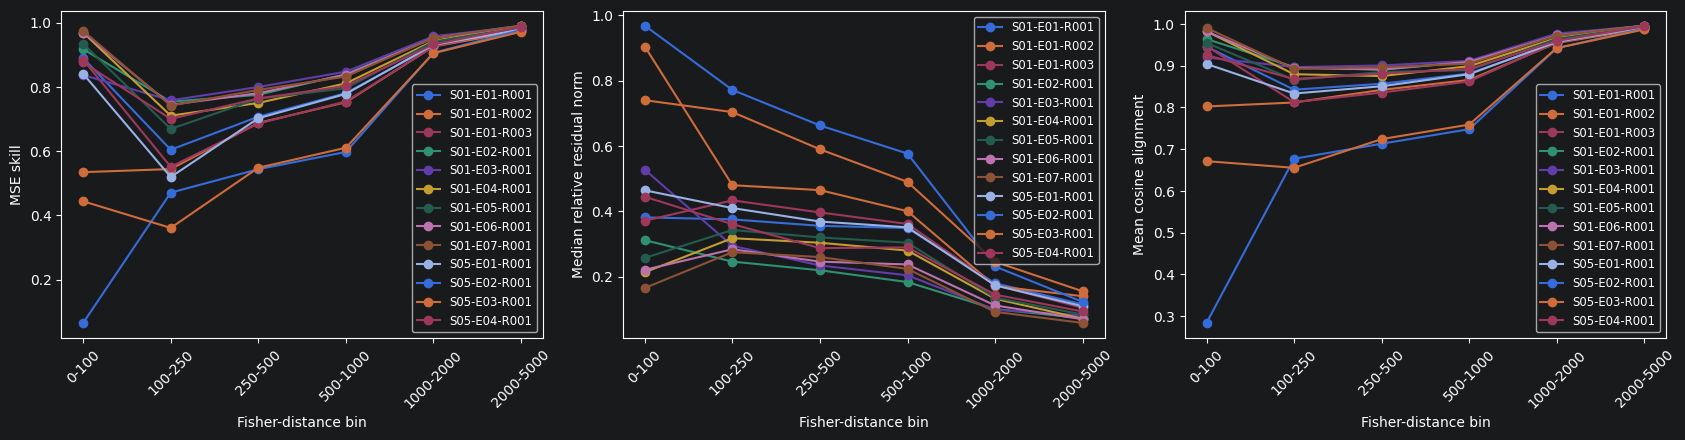

In [9]:
if distance_bins.empty:
    display(Markdown("No Fisher-distance diagnostics are available."))
else:
    display(distance_bins.sort_values(["run_id", "distance_bin_lo"])[["run_id", "distance_bin", "sample_count", "mean_fisher_distance_l2", "mse_skill", "median_relative_residual_norm", "mean_cosine_alignment", "mean_correction_norm_ratio"]])
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    cplots.plot_mse_skill_by_distance_bin(distance_bins, ax=axes[0])
    cplots.plot_relative_residual_by_distance_bin(distance_bins, ax=axes[1])
    cplots.plot_cosine_alignment_by_distance_bin(distance_bins, ax=axes[2])
    fig.tight_layout()
    plt.show()

## 10. Selected Prediction Diagnostics

This section loads pair-level predictions lazily for one selected complete run. Set `SELECTED_RUN` in the setup cell to inspect a specific run.

Selected run: `S01-E03-R001` with 2048 validation pairs.

,pair_record_id,eval_slice,fisher_distance_l2,truth_norm,pred_norm,residual_norm,cosine_alignment,correction_norm_ratio,relative_residual_norm
0,eval_pair_284062ec04ef7365be63,heldout_science_seen_nuisance,1204.159424,1204.159458,1071.933671,892.277290,0.698370,0.890192,0.740996
1,eval_pair_83de2c27e6debcd5c4ee,heldout_science_seen_nuisance,1204.159424,1204.159458,1092.978797,874.077308,0.714445,0.907669,0.725882
2,eval_pair_4b665de542a58fcc0ab5,heldout_science_seen_nuisance,781.024963,781.024968,712.844510,342.955192,0.898545,0.912704,0.439109
3,eval_pair_2c7f6e7afb36f72542a8,heldout_science_seen_nuisance,781.024963,781.024968,756.500521,342.552320,0.901209,0.968600,0.438593
4,eval_pair_54e54b6d3b1afecc1e5c,heldout_science_seen_nuisance,447.213593,447.213595,670.717198,375.687651,0.847998,1.499769,0.840063
5,eval_pair_2f10ac5c58f8c3552695,heldout_science_seen_nuisance,447.213593,447.213595,651.657615,351.966738,0.859172,1.457151,0.787022
6,eval_pair_35fde2a59e954df612b7,heldout_science_seen_nuisance,300.000000,300.000000,231.682301,120.715479,0.928746,0.772274,0.402385
7,eval_pair_82b9bfd561f1e9fc6eb7,heldout_science_seen_nuisance,300.000000,300.000000,227.636037,110.010936,0.949731,0.758787,0.366703
8,eval_pair_a79ad23bed1e61a162ee,heldout_science_seen_nuisance,1868.154175,1868.154169,1824.432472,403.806513,0.976360,0.976596,0.216153
9,eval_pair_7702c49dcb3fb06c7de6,heldout_science_seen_nuisance,1868.154175,1868.154169,1822.409177,397.978788,0.977046,0.975513,0.213033


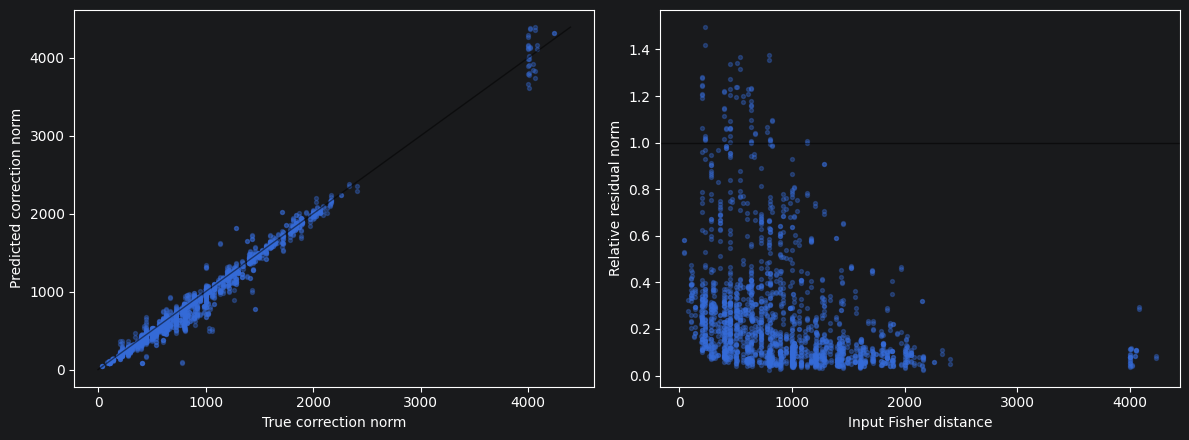

In [10]:
selected_run = SELECTED_RUN
if selected_run is None and not runs.empty:
    complete = runs[runs["status"] == "complete"].sort_values("best_fisher_rmse", na_position="last")
    selected_run = None if complete.empty else str(complete.iloc[0]["run_id"])

if selected_run is None:
    display(Markdown("No complete run is available for prediction-level diagnostics."))
elif selected_run not in campaign.run_records:
    display(Markdown(f"Selected run `{selected_run}` is not available in the local campaign."))
else:
    pred = campaign.load_predictions(selected_run)
    display(Markdown(f"Selected run: `{selected_run}` with {len(pred.geometry)} validation pairs."))
    display(pred.geometry[[c for c in ["pair_record_id", "eval_slice", "fisher_distance_l2", "truth_norm", "pred_norm", "residual_norm", "cosine_alignment", "correction_norm_ratio", "relative_residual_norm"] if c in pred.geometry]].head(20))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    cplots.plot_prediction_norms(pred.geometry, ax=axes[0])
    cplots.plot_relative_residual_vs_distance(pred.geometry, ax=axes[1])
    fig.tight_layout()
    plt.show()

## 11. Notes / Next Questions

- Use S05 comparisons to separate representation effects from optimizer effects.
- Use S01-E02 through S01-E07 to compare fixed, plateau, and cosine learning-rate policies once synchronized.
- Treat test-evaluated runs as flagged provenance, not validation-tuning evidence.